In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

CRF(8%, 5y) = 0.3880
Effective hours/year = 7,008

Technology              Capex $/GB     $/GB-hour    $/GB-month
SRAM                        200.00       0.01107      8.084032
HBM4e                        15.00       0.00083      0.606302
LPDDR5X                      14.00       0.00078      0.565882
DDR5                         12.00       0.00066      0.485042
SSD                           0.75       0.00004      0.030315


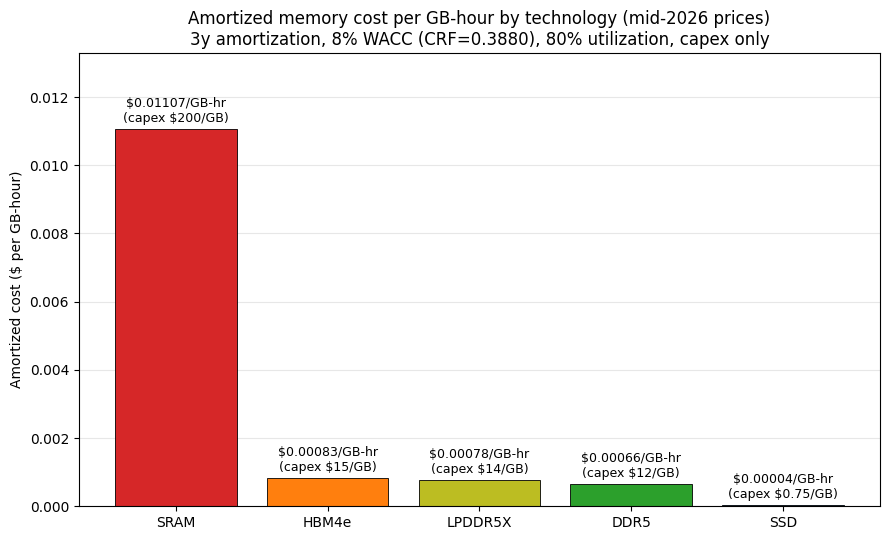

In [2]:
"""
METHOD
------
$/GB-hour = capex_per_GB * CRF(WACC, N) / (hours_per_year * utilization)

CRF (capital recovery factor) converts upfront capex into an equivalent
annual payment including cost of capital:
    CRF = r * (1+r)^N / ((1+r)^N - 1)

FINANCIAL ASSUMPTIONS
---------------------
- Amortization period N = 5 years
- WACC r = 8%  -> CRF(0.08, 5) = 0.2505 (25.05% of capex per year)
- Utilization = 80% (cost is spread only over utilized GB-hours)
- Opex (power, cooling, controller/host overhead) EXCLUDED: pure capital
  cost of the memory itself. SRAM leakage power in particular would add
  materially to its real TCO.

PRICE ASSUMPTIONS (capex $/GB, mid-2026 market)
-----------------------------------------------
Context: the 2025-26 AI-driven memory shortage pushed DRAM and NAND
prices up 2-4x. Chip-level DDR5 currently trades near HBM3e contract
prices, which is historically abnormal.

- SRAM (on-die, N5-class):  $200/GB  [derived estimate, no market price]
    Derivation: HD bitcell ~0.021 um^2 (N5), ~50% array efficiency
    -> ~360 mm^2 of silicon per GB. Leading-edge wafer $17-30k per
    300 mm wafer (~$0.25-0.45/mm^2) -> $90-160/GB raw silicon; yield,
    test and design overhead push realistic cost to $100-500/GB.
    Sources: TechSpot (TSMC N2 wafer $30k, Jun 2025),
    siliconanalysts.com/guide/semiconductor-costs (N3 ~$19.5k/wafer).
- HBM4e:                    $15/GB   [contract]
    $13-17/GB early 2026, +~20% hikes for 2026 orders.
    Sources: siliconanalysts.com/market-data, TrendForce (Dec 2025),
    Goldman Sachs via Jukan.
    For GB200, HBM3e (192GB) + packaging cost $3.9k and 150W (HBM3 runs roughly 3.5 to 5 pJ/bit including PHY (HBM2e was ~6-7, HBM3e pushes toward 3) + all operational costs.
- DDR5:                     $12/GB   [chip-level contract, ~$1.50/Gbit]
    Spot peaked at $27.20/GB Dec 2025; server RDIMM street $30-39/GB.
    Sources: TechPowerUp/Counterpoint (Jan 2026), tech-insider.org,
    capitalandcompute.net (Aug 2026).
- LPDDR5X:                  $14/GB   [estimate, chip-level]
    Contract +78-83% QoQ in Q2 2026, near DDR5 parity.
    Sources: TrendForce via BigGo Finance (May 2026), Counterpoint.
- Enterprise SSD (TLC):     $0.75/GB [street, 30TB drive $22,600]
    Source: VDURA Flash Volatility Index Aug 2026 via Tom's Hardware.

CAVEATS
-------
- Bases differ: SRAM is a cost derivation, HBM/DDR5/LPDDR5X are contract
  or chip-level prices, SSD is a street price. Ratios are the signal,
  not the third significant digit.
- 5-year amortization is generous for leading-edge SRAM/HBM (typically
  bundled with an accelerator on a 3-5 year depreciation schedule).
"""

import matplotlib.pyplot as plt
import numpy as np
from seaborn.matrix import dendrogram

# --- Parameters ---------------------------------------------------------
WACC = 0.08
YEARS = 3
UTILIZATION = 0.80
HOURS_PER_YEAR = 8760

# Capital recovery factor
CRF = WACC * (1 + WACC) ** YEARS / ((1 + WACC) ** YEARS - 1)  # 0.25046

# Capex $/GB (see header for sources)
PRICE_PER_GB = {
    "SRAM": 200.0,
    "HBM4e": 15.0,
    "LPDDR5X": 14.0,
    "DDR5": 12.0,
    "SSD": 0.75,
}

# --- Compute $/GB-hour --------------------------------------------------
cost_per_gb_hour = {
    k: p * CRF / (HOURS_PER_YEAR * UTILIZATION) for k, p in PRICE_PER_GB.items()
}

# --- Plot (non-log scale, fixed-point annotations) ------------------------
labels = list(cost_per_gb_hour.keys())
values = [cost_per_gb_hour[k] for k in labels]
colors = ["#d62728", "#ff7f0e", "#bcbd22", "#2ca02c", "#1f77b4"]

fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.bar(labels, values, color=colors, edgecolor="black", linewidth=0.6)

# Normal (not log) scale for y-axis
ax.set_ylabel("Amortized cost ($ per GB-hour)")
ax.set_title(
    "Amortized memory cost per GB-hour by technology (mid-2026 prices)\n"
    f"3y amortization, {WACC:.0%} WACC (CRF={CRF:.4f}), "
    f"{UTILIZATION:.0%} utilization, capex only"
)
ax.grid(axis="y", which="both", alpha=0.3)
ax.set_axisbelow(True)

for bar, v, (k, p) in zip(bars, values, PRICE_PER_GB.items()):
    ax.annotate(
        f"${v:.5f}/GB-hr\n(capex ${p:g}/GB)",
        xy=(bar.get_x() + bar.get_width() / 2, v),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
        fontsize=9,
    )

ax.set_ylim(0, max(values) * 1.2)
fig.tight_layout()
fig.savefig("memory_cost_per_gb_hour.png", dpi=200)

# --- Console output -----------------------------------------------------
print(f"CRF(8%, 5y) = {CRF:.4f}")
print(f"Effective hours/year = {HOURS_PER_YEAR * UTILIZATION:,.0f}\n")
print(f"{'Technology':<22}{'Capex $/GB':>12}{'$/GB-hour':>14}{'$/GB-month':>14}")
for k, p in PRICE_PER_GB.items():
    h = cost_per_gb_hour[k]
    print(f"{k.replace(chr(10), ' '):<22}{p:>12.2f}{h:>14.5f}{h * 730:>14.6f}")

CRF(8%, 3y) = 0.3880
Effective hours/year = 7,008

Technology                 $/GB-hour    $/GB-month
SRAM                         0.01820     13.286000
HBM4e                        0.00250      1.825000
LPDDR5X                      0.00190      1.387000
DDR5                         0.00180      1.314000
SSD                          0.00120      0.876000


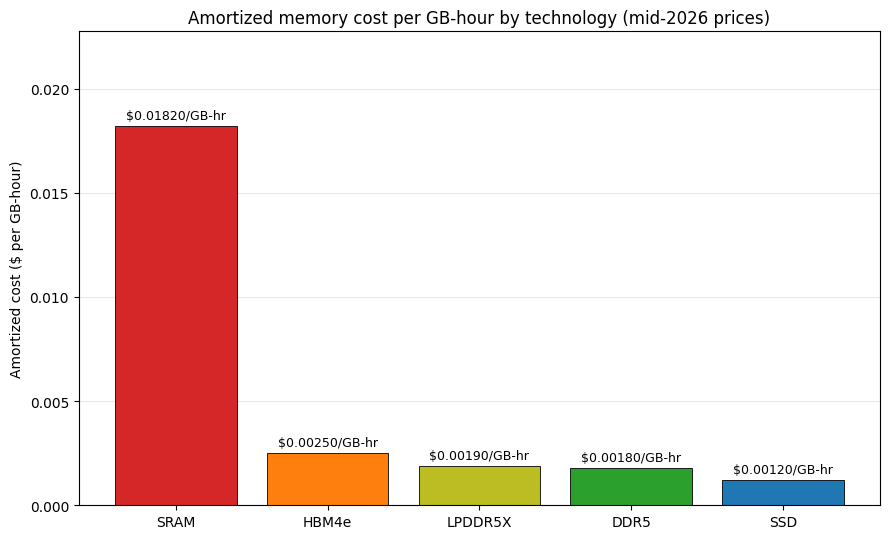

In [5]:
import matplotlib.pyplot as plt

# --- Parameters ---------------------------------------------------------
SRAM = 0.0182   # 288W
HBM = 0.0025    # 150W
DDR = 0.0018    # 40W
LPDDR = 0.0019  # 30W
SSD = 0.0012    # 15W

cost_per_gb_hour = {
    "SRAM": SRAM,
    "HBM4e": HBM,
    "LPDDR5X": LPDDR,
    "DDR5": DDR,
    "SSD": SSD,
}

# --- Plot ----------------------------------------------------------------
labels = list(cost_per_gb_hour.keys())
values = [cost_per_gb_hour[k] for k in labels]
colors = ["#d62728", "#ff7f0e", "#bcbd22", "#2ca02c", "#1f77b4"]

fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.bar(labels, values, color=colors, edgecolor="black", linewidth=0.6)

ax.set_ylabel("Amortized cost ($ per GB-hour)")
ax.set_title(
    "Amortized memory cost per GB-hour by technology (mid-2026 prices)"
)
ax.grid(axis="y", which="both", alpha=0.3)
ax.set_axisbelow(True)

for bar, v, k in zip(bars, values, labels):
    ax.annotate(
        f"${v:.5f}/GB-hr",
        xy=(bar.get_x() + bar.get_width() / 2, v),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
        fontsize=9,
    )

ax.set_ylim(0, max(values) * 1.25)
fig.tight_layout()
fig.savefig("memory_cost_per_gb_hour.png", dpi=200)

# --- Console output -----------------------------------------------------
print(f"CRF(8%, {YEARS}y) = {CRF:.4f}")
print(f"Effective hours/year = {HOURS_PER_YEAR * UTILIZATION:,.0f}\n")
print(f"{'Technology':<22}{'$/GB-hour':>14}{'$/GB-month':>14}")
for k, h in cost_per_gb_hour.items():
    print(f"{k:<22}{h:>14.5f}{h * 730:>14.6f}")

In [ ]:
# Run 1: capex-only model (SRAM $200/GB, CRF 0.3880 despite the "5y" label)
v1 = {
    "SRAM":    0.01107,
    "HBM4e":   0.00083,
    "LPDDR5X": 0.00078,
    "DDR5":    0.00066,
    "SSD":     0.00004,
}

# Run 2: all-in model (SRAM derived $340.79/GB + 92% overhead, others hardcoded)
v2 = {
    "SRAM":    0.01820,
    "HBM4e":   0.00250,
    "LPDDR5X": 0.00190,
    "DDR5":    0.00180,
    "SSD":     0.00120,
}

print(f"{'Technology':<10}{'v1 $/GB-hr':>12}{'v2 $/GB-hr':>12}{'diff':>12}{'diff %':>10}")
for k in v1:
    a, b = v1[k], v2[k]
    print(f"{k:<10}{a:>12.5f}{b:>12.5f}{b - a:>+12.5f}{(b - a) / a * 100:>+9.1f}%")

print(f"\n{'Technology':<10}{'v1 $/GB-mo':>12}{'v2 $/GB-mo':>12}{'diff':>12}")
m1 = {"SRAM": 8.084032, "HBM4e": 0.606302, "LPDDR5X": 0.565882, "DDR5": 0.485042, "SSD": 0.030315}
m2 = {"SRAM": 26.447879, "HBM4e": 1.825000, "LPDDR5X": 1.387000, "DDR5": 1.314000, "SSD": 0.876000}
for k in m1:
    print(f"{k:<10}{m1[k]:>12.4f}{m2[k]:>12.4f}{m2[k] - m1[k]:>+12.4f}")

Technology  v1 $/GB-hr  v2 $/GB-hr        diff    diff %
SRAM           0.01107     0.01820    +0.00713    +64.4%
HBM4e          0.00083     0.00250    +0.00167   +201.2%
LPDDR5X        0.00078     0.00190    +0.00112   +143.6%
DDR5           0.00066     0.00180    +0.00114   +172.7%
SSD            0.00004     0.00120    +0.00116  +2900.0%

Technology  v1 $/GB-mo  v2 $/GB-mo        diff
SRAM            8.0840     26.4479    +18.3638
HBM4e           0.6063      1.8250     +1.2187
LPDDR5X         0.5659      1.3870     +0.8211
DDR5            0.4850      1.3140     +0.8290
SSD             0.0303      0.8760     +0.8457


PREFILL — computing the 1M-token KV cache once
Work: 946.1 PFLOP total
  weight GEMMs      208.0 PFLOP (22.0%)  [FP4 path, MFU 50%]
  MLA attention     737.3 PFLOP (77.9%)  [FP8 path, MFU 40%]
  KDA state ops       0.9 PFLOP ( 0.1%)  [FP8 path, MFU 40%]
Time: 397 chip-seconds  =  6 s wall-clock on 72 GPUs (0.1 min)

ASSUMPTIONS
Cache stored: 14.3 GB (13.8 GB MLA KV + 0.5 GB KDA state)
Memory tiers: hardcoded all-in $/GB-hour (capex amortization + power/cooling/host overhead)
Access escalator: +5% of base price per additional req/hr (memory only)
Hot start: 1 cold prefill ($0.108 at GB300 @ 1400W) amortized over 1 h, added to all storage costs
Realism [TraceLab-calibrated]: hit rate 90% (misses pay full recompute)  |  reload overlap 65%
Pool efficiency per tier: hot (SRAM/HBM4e/LPDDR5X) 60%, cold (DDR5/SSD) 30%
Baseline reuse rate: 30 req/hr

RECOMPUTE COST (per chip scenario, @30 req/hr)
Scenario                     $/prefill recompute $/hr   BE vs HBM4e
                               

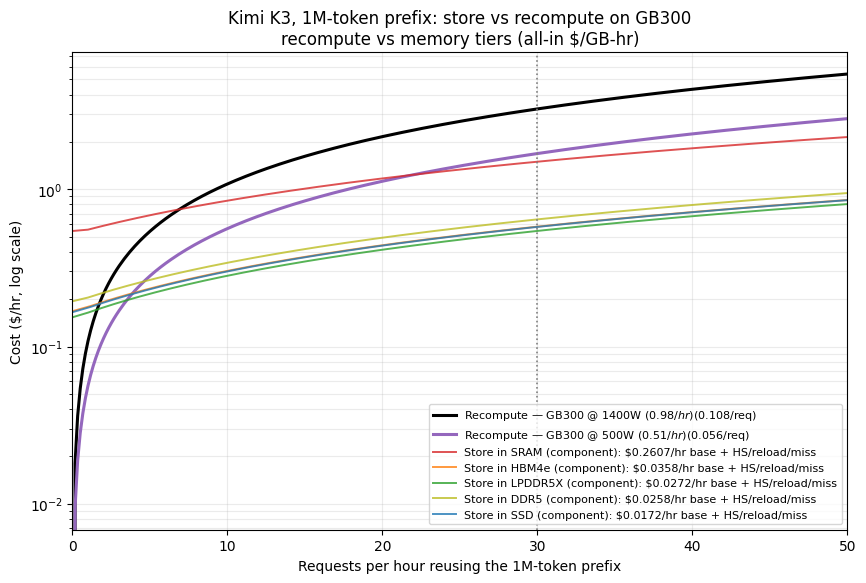

In [ ]:
"""
Store vs recompute: KV cache economics for Kimi K3 on GB300.

QUESTION
--------
For a 1M-token prefix reused R times per hour, is it cheaper to keep the
KV cache resident (pay memory $/GB-hr) or to recompute the prefill on
every request (pay compute $/request)?

MODEL: KIMI K3 (Moonshot AI, July 2026)
---------------------------------------
- 2.8T total params, 104B active (16/896 experts, Stable LatentMoE)
  [morphllm.com/kimi-k3, model card Sep 2026]
- 93 text-backbone layers: 69 KDA (linear attention, constant-size
  recurrent state) + 24 Gated MLA (per-token latent KV), pattern
  KDA x3 -> MLA x1  [AMD Kimi-K3 deployment article]
- MXFP4 weights (QAT), ~1.4TB checkpoint  [HF blog]
- MLA latent: 576 dims/token/layer (512 nope + 64 rope, DeepSeek-style),
  FP8 KV -> 24 * 576 * 1B * 1e6 = 13.8 GB per 1M tokens. Matches the
  14 GB working assumption.
- KDA state: constant size per request, does NOT scale with tokens.
  Derivation: delta-rule state = n_heads * d_k * d_v per layer
  ~= 32-64 * 128 * 128 * FP16 ~= 1-2 MB/layer -> ~0.1-0.5 GB across
  69 layers incl. conv states. Exact prefix reuse requires storing it
  (vLLM state-aware prefix caching) but it is economically negligible
  next to the 14 GB MLA KV. Default 0.5 GB.

PREFILL FLOPs (this IS the cost of "computing the KV cache" — layer N's
KV requires the full forward pass through layers 1..N-1)
--------------------------------------------------------
1. Weight GEMMs: 2 * N_active * L (projections + MoE FFN)
2. Quadratic attention, MLA layers only:
   FLOPs/layer = L^2 * n_heads * (d_qk + d_v)   [causal 0.5 * 2 matmuls
   * 2 FLOP/MAC, non-absorbed prefill]. Head config assumed = Kimi K2
   (64 heads, d_qk=192, d_v=128); K3 technical report pending.
3. KDA state ops: linear in L; small (~0.1% of total).

HARDWARE SCENARIOS: GB300 (B300 GPU)
------------------------------------
Peak per GPU: 15 PFLOPS dense NVFP4, 5 PFLOPS dense FP8, 288 GB HBM3e,
8 TB/s, 1400 W TDP [verda.com/blog/gb300-nvl72-architecture].
MFU: 50% on MXFP4 GEMMs, 40% effective on attention.

Chip rates are EX-HBM: derived from a BOM analysis with the HBM
capex removed from the chip cost. All-in otherwise (WACC, PUE,
energy...). HBM is therefore priced separately, via the component
tier below.

A. "GB300 @ 1400W": $0.98/chip/hr ex-HBM, full throughput.
B. "GB300 @ 500W":  $0.51/chip/hr ex-HBM, power-capped. BY ASSUMPTION
   the cap carries no throughput loss (perf_derate = 1.0): compute
   capacity is identical to the 1400 W scenario. PERF_DERATE_B remains
   available for sensitivity if that assumption is revisited.

STORAGE TIERS — METHOD
----------------------
Component tiers are HARDCODED all-in $/GB-hour figures (capex
amortization + overhead: power, cooling, controller/host share),
supplied directly rather than derived in this script:

- SRAM:     $0.01820/GB-hr  [area-derived capex ~$341/GB at 1 MB/mm^2,
            $20k N5/N3 wafer, 85% usable, + overhead]
- HBM4e:    $0.00250/GB-hr  [~150 W for 192 GB class]
- LPDDR5X:  $0.00190/GB-hr  [~30 W]
- DDR5:     $0.00180/GB-hr  [~40 W]
- SSD:      $0.00120/GB-hr  [~15 W]

Note SRAM and DDR5 are included for completeness of the memory
hierarchy; neither is a realistic 26GB KV offload tier on GB300 (26GB
of on-die SRAM does not exist on any chip except wafer-scale, and the
GB300 host memory is LPDDR5X, not DDR5).


HOT START (cold prefill before storing)
---------------------------------------
Storing is not free at t=0: the cache must be COMPUTED ONCE before it
can be reused. Every storage curve/table therefore includes one prefill
at the reference chip scenario (HOT_START_SCENARIO), spread over
HOT_START_AMORT_HOURS (default 1 h = the whole cost lands in the
displayed hour, worst case for storage; raise it for longer-lived
sessions). Consequence: below ~1 reuse/hr storage can no longer beat
recompute — the first computation is common to both strategies — and
every breakeven shifts right by roughly one request.

ACCESS ESCALATOR
----------------
Storage cost is no longer flat in request rate: each ADDITIONAL request
per hour beyond the first adds 5% of the tier's original (1-request)
hourly price. cost_hr(R) = base_hr * (1 + 0.05 * max(R - 1, 0)).
Models access-linked cost (bandwidth occupancy, cache management I/O)
on the memory side only; compute cost per recompute is unchanged.
Consequence: storage lines now slope upward; a tier only ever breaks
even against recompute if $/recompute > 5% of its base hourly price,
otherwise storage stays cheaper (or dearer) at all rates.

REALISM EXTENSIONS (reload idle, hit rate, pool efficiency)
-----------------------------------------------------------
Three effects the pure occupancy model misses, now priced:
1. RELOAD IDLE: fetching the cache from an off-chip tier stalls the GPU
   for stored_gb / tier_bandwidth * (1 - OVERLAP_FACTOR) seconds per
   access. OVERLAP_FACTOR = share of the transfer hidden by prefetch/
   streaming; bimodal by trigger [TraceLab]: tool-triggered reloads are
   predictable (tool latency known at call time; >1min calls are 4-5%
   of calls but 61-92% of total time) -> 85-95% overlap; user-triggered
   reloads (the ones that missed the TTL) get a few seconds of signal
   from keystroke/session-open, >> the ~1.4 s a 14 GB SSD reload needs
   -> 70-90% with signal, 20-40% without (layer pipelining only, median
   append ~875 tokens masks little). Weighted by where off-chip reloads
   actually occur (mostly human returns): base 65%, bull 85%
   (Mooncake-style prefetch on activity signals), bear 35%. Idle chip-time is priced at the
   scenario's own rate. Tier bandwidths (GB/s): HBM4e pool 900 (NVLink),
   LPDDR5X 900 (Grace C2C), DDR5 64 (CXL/PCIe5), SSD 10 (NVMe RAID),
   SRAM in-place (no reload).
2. HIT RATE: only HIT_RATE of the R requests find a live cache; misses
   pay a full recompute at the scenario rate. Base 90% (TraceLab: ~94%
   attainable at 5 min TTL; 85.4-98.6% across the eviction sweep).
3. POOL EFFICIENCY: caches are held for users who never return or are
   evicted early; effective holding cost = base / pool_efficiency,
   PER TIER. Calibration from TraceLab agentic traces
   [arxiv.org/html/2606.30560]: eviction sweep 1min->1h moves hit rate
   85.4%->98.6% but storage ratio R=0.74->5.07; at 5 min TTL, ~94% hit
   for R~1.9; the 5min->1h slice stores 2.7x more GB-hours for ~4 pts
   of reuse (marginal efficiency 10-20%). Gap distributions (human
   median 1.4 min, p90 20.6 min; tool gaps in seconds; 86% of steps
   tool-triggered) give: hot tier (SRAM/HBM/DRAM, TTL ~5 min) 50-70%,
   base 60%; cold tier (DDR/SSD, hours of retention, abandoned
   sessions) 15-40%, base 30%. TraceLab is a single-user researcher
   trace, so cold-tier waste is likely underestimated for a fleet.
Storage strategy $/hr = hot_start/H + holding(base/pool_eff, R)
   + R * [hit * reload_idle_cost + (1-hit) * $/recompute].
NOT modeled (see analysis notes): bandwidth contention/convexity, SSD
endurance, TTFT SLOs, routing/locality, opex, mass invalidation on
model updates, KV compression, hybrid policies.

CAVEATS
-------
- Assumes the full 1M prefix is bit-identical across requests.
- K3 MLA head config inferred from K2; update when the tech report lands.
- Tier $/GB-hr figures are point estimates on mixed bases; ratios are
  the signal, not the third significant digit.
"""

import matplotlib.pyplot as plt
import numpy as np

# ---------------- Parameters ----------------
ISL = 1_000_000
N_ACTIVE = 104e9
N_MLA_LAYERS, N_KDA_LAYERS = 24, 69
N_HEADS, D_QK, D_V = 96, 192, 128
KDA_D, KDA_C = 128, 4

MLA_LATENT_BYTES = 576          # 576 dims x FP8 (1B) per token per MLA layer
KV_GB = ISL * N_MLA_LAYERS * MLA_LATENT_BYTES / 1e9   # 13.8 GB @ 1M, scales with ISL
KDA_STATE_GB = 0.5
INCLUDE_KDA_STATE = True

FP4_DENSE, FP8_DENSE = 15e15, 5e15
MFU_GEMM, MFU_ATTN = 0.50, 0.40
HBM_PER_CHIP_GB = 288.0

PERF_DERATE_B = 1.0   # sustained-throughput factor at the 500 W cap
N_GPUS = 72           # NVL72 GB300 rack as the prefill system: 72 GPUs
                      # in one NVLink domain (1.1 EFLOPS dense FP4,
                      # 20.7 TB HBM). Affects WALL TIME only — cost is
                      # chip-seconds x rate, parallelism-invariant;
                      # scaling losses folded into MFU. Weights floor
                      # is 8 GPUs (1.4TB); 72 gives TP/EP/CP headroom.

SCENARIOS = {
    "GB300 @ 1400W ($0.98/hr)": {"rate": 0.98, "derate": 1.0,
                                 "color": "black", "ls": "-"},
    "GB300 @ 500W ($0.51/hr)":  {"rate": 0.51, "derate": PERF_DERATE_B,
                                 "color": "#9467bd", "ls": "-"},
}

REQ_PER_HOUR_BASE = 30.0
PRICE_INCREASE_PER_ADDL_REQ = 0.05   # of original price, memory tiers only
HOT_START_SCENARIO = "GB300 @ 1400W ($0.98/hr)"  # chip pricing the initial prefill
HOT_START_AMORT_HOURS = 1.0          # hours over which the cold prefill is spread
HIT_RATE = 0.90          # share of requests that find a live cache
                         # [TraceLab: ~94% at 5 min TTL]
OVERLAP_FACTOR = 0.65    # share of reload transfer hidden behind other work
                         # [base 65%; bull 85% (prefetch on signals), bear 35%]
POOL_EFF_PER_TIER = {    # share of stored GB-hours serving a returning user
    "SRAM (component)": 0.60,     # hot tier, TTL ~5 min [TraceLab 50-70%]
    "HBM4e (component)": 0.60,    # hot tier
    "LPDDR5X (component)": 0.60,  # hot tier (host DRAM)
    "DDR5 (component)": 0.30,     # cold tier, hours retention [15-40%]
    "SSD (component)": 0.30,      # cold tier
}

TIER_BW_GBS = {          # reload bandwidth to HBM, GB/s (None = in place)
    "SRAM (component)": None,
    "HBM4e (component)": 900.0,
    "LPDDR5X (component)": 900.0,
    "DDR5 (component)": 64.0,
    "SSD (component)": 10.0,
}


def storage_cost_hr(base_hr, req_per_hr):
    """Hourly storage cost with the 5%-of-original-per-additional-request
    escalator. Works on scalars or numpy arrays of request rates."""
    return base_hr * (1 + PRICE_INCREASE_PER_ADDL_REQ
                      * np.maximum(req_per_hr - 1, 0))


def reload_idle_cost(gb, bw_gbs, chip_rate):
    """$ of stranded chip-time per cache access from an off-chip tier."""
    if bw_gbs is None:
        return 0.0
    idle_s = gb / bw_gbs * (1 - OVERLAP_FACTOR)
    return idle_s / 3600 * chip_rate


def storage_total_hr(base_hr, req_per_hr, hot_start_cost,
                     reload_cost=0.0, rc_miss=0.0, pool_eff=0.60):
    """Hourly cost of the storage strategy: escalated holding cost
    (degraded by the tier's pool efficiency) + cold prefill spread over
    HOT_START_AMORT_HOURS + per-access reload idle on hits + full
    recomputes on misses."""
    return (storage_cost_hr(base_hr / pool_eff, req_per_hr)
            + hot_start_cost / HOT_START_AMORT_HOURS
            + req_per_hr * (HIT_RATE * reload_cost
                            + (1 - HIT_RATE) * rc_miss))


def breakeven_rate(base_hr, cost_per_recompute, hot_start_cost=0.0,
                   reload_cost=0.0, pool_eff=0.60):
    """Solve R: cost_per_recompute * R = storage_total_hr(...). Both
    sides are linear in R. Returns None if recompute never overtakes."""
    eb = base_hr / pool_eff
    denom = (HIT_RATE * (cost_per_recompute - reload_cost)
             - PRICE_INCREASE_PER_ADDL_REQ * eb)
    if denom <= 0:
        return None
    r = ((1 - PRICE_INCREASE_PER_ADDL_REQ) * eb
         + hot_start_cost / HOT_START_AMORT_HOURS) / denom
    return max(r, 0)

# ---------------- Memory tiers: all-in $/GB-hour (hardcoded) ----------------
component_tiers = {
    "SRAM (component)": 0.01820,
    "HBM4e (component)": 0.00250,
    "LPDDR5X (component)": 0.00190,
    "DDR5 (component)": 0.00180,
    "SSD (component)": 0.00120,
}
tier_colors = {"SRAM (component)": "#d62728",
               "HBM4e (component)": "#ff7f0e",
               "LPDDR5X (component)": "#2ca02c",
               "DDR5 (component)": "#bcbd22",
               "SSD (component)": "#1f77b4"}

# ---------------- Prefill FLOPs (scenario-independent) ----------------
flops_gemm = 2 * N_ACTIVE * ISL
flops_attn = ISL**2 * N_HEADS * (D_QK + D_V) * N_MLA_LAYERS
flops_kda = 2 * N_HEADS * KDA_D**2 * KDA_C * ISL * N_KDA_LAYERS

base_chip_seconds = (flops_gemm / (FP4_DENSE * MFU_GEMM)
                     + (flops_attn + flops_kda) / (FP8_DENSE * MFU_ATTN))

# ---------------- Hot start: one prefill at the reference scenario ------
HOT_START_COST = (base_chip_seconds / SCENARIOS[HOT_START_SCENARIO]["derate"]
                  / 3600 * SCENARIOS[HOT_START_SCENARIO]["rate"])

# ---------------- Storage size ----------------
stored_gb = KV_GB + (KDA_STATE_GB if INCLUDE_KDA_STATE else 0.0)

# ---------------- Compute per scenario ----------------
rates_sweep = np.linspace(0, 50, 300)
fig, ax = plt.subplots(figsize=(10, 6.2))

PF = 1e15  # 1 PFLOP
flops_total = flops_gemm + flops_attn + flops_kda

print("=" * 74)
isl_label = f"{ISL/1e6:g}M" if ISL >= 1e6 else f"{ISL/1e3:g}k"
print(f"PREFILL — computing the {isl_label}-token KV cache once")
print("=" * 74)
print(f"Work: {flops_total/PF:,.1f} PFLOP total")
print(f"  weight GEMMs   {flops_gemm/PF:>8,.1f} PFLOP "
      f"({flops_gemm/flops_total:5.1%})  [FP4 path, MFU {MFU_GEMM:.0%}]")
print(f"  MLA attention  {flops_attn/PF:>8,.1f} PFLOP "
      f"({flops_attn/flops_total:5.1%})  [FP8 path, MFU {MFU_ATTN:.0%}]")
print(f"  KDA state ops  {flops_kda/PF:>8,.1f} PFLOP "
      f"({flops_kda/flops_total:5.1%})  [FP8 path, MFU {MFU_ATTN:.0%}]")
print(f"Time: {base_chip_seconds:,.0f} chip-seconds  =  "
      f"{base_chip_seconds/N_GPUS:,.0f} s wall-clock on {N_GPUS} GPUs "
      f"({base_chip_seconds/N_GPUS/60:.1f} min)")

print()
print("=" * 74)
print("ASSUMPTIONS")
print("=" * 74)
print(f"Cache stored: {stored_gb:.1f} GB "
      f"({KV_GB:.1f} GB MLA KV"
      + (f" + {KDA_STATE_GB:.1f} GB KDA state)" if INCLUDE_KDA_STATE
         else " only; KDA state excluded)"))
print(f"Memory tiers: hardcoded all-in $/GB-hour "
      f"(capex amortization + power/cooling/host overhead)")
print(f"Access escalator: +{PRICE_INCREASE_PER_ADDL_REQ:.0%} of base price "
      f"per additional req/hr (memory only)")
print(f"Hot start: 1 cold prefill (${HOT_START_COST:.3f} at "
      f"{HOT_START_SCENARIO.split(' (')[0]}) amortized over "
      f"{HOT_START_AMORT_HOURS:g} h, added to all storage costs")
print(f"Realism [TraceLab-calibrated]: hit rate {HIT_RATE:.0%} "
      f"(misses pay full recompute)  |  reload overlap {OVERLAP_FACTOR:.0%}")
print(f"Pool efficiency per tier: hot (SRAM/HBM4e/LPDDR5X) 60%, "
      f"cold (DDR5/SSD) 30%")
print(f"Baseline reuse rate: {REQ_PER_HOUR_BASE:.0f} req/hr")

print()
print("=" * 74)
print(f"RECOMPUTE COST (per chip scenario, @{REQ_PER_HOUR_BASE:.0f} req/hr)")
print("=" * 74)
print(f"{'Scenario':<28}{'$/prefill':>10}{'recompute $/hr':>15}"
      f"{'BE vs HBM4e':>14}")
print(f"{'':<28}{'':>10}{'':>15}{'req/hr':>14}")
hbm4e_base_hr = component_tiers["HBM4e (component)"] * stored_gb
hbm4e_bw = TIER_BW_GBS["HBM4e (component)"]

results = {}
for name, sc in SCENARIOS.items():
    chip_s = base_chip_seconds / sc["derate"]
    rc = chip_s / 3600 * sc["rate"]                    # $/recompute
    results[name] = rc
    # Scenario-consistent world: hot start, misses and reload idle are
    # all priced at THIS scenario's own rate, so the breakeven dot sits
    # exactly on the intersection of the two plotted curves.
    rl_sc = reload_idle_cost(stored_gb, hbm4e_bw, sc["rate"])
    be_tab = breakeven_rate(hbm4e_base_hr, rc, rc, rl_sc,
                            POOL_EFF_PER_TIER["HBM4e (component)"])
    print(f"{name:<28}{rc:>10.3f}{rc*REQ_PER_HOUR_BASE:>15.2f}"
          f"{(f'{be_tab:.2f}' if be_tab is not None else 'never'):>14}")

    ax.plot(rates_sweep, rc * rates_sweep, color=sc["color"], ls=sc["ls"],
            lw=2.2, label=f"Recompute — {name} (${rc:.3f}/req)")

print()
print("=" * 74)
print(f"MEMORY TIERS — cost to hold {stored_gb:.0f} GB (all-in $/GB-hr)")
print("=" * 74)
print(f"{'Tier':<24}{'$/GB-hr':>10}{'hold':>9}{'reload':>9}{'total':>9}{'vs rcmp':>9}{'breakeven':>11}")
print(f"{'':<24}{'':>10}{'$/hr@1':>9}{'idle s':>9}"
      f"{'$/hr@' + format(REQ_PER_HOUR_BASE, '.0f'):>9}"
      f"{'@' + format(REQ_PER_HOUR_BASE, '.0f'):>9}{'req/hr':>11}")
ref_name = HOT_START_SCENARIO
rc_ref_per_req = results[ref_name]
rc_ref = rc_ref_per_req * REQ_PER_HOUR_BASE
ref_rate = SCENARIOS[ref_name]["rate"]
for tname, trate in component_tiers.items():
    c = trate * stored_gb   # base (1-request) holding cost, excl. hot start
    pe = POOL_EFF_PER_TIER[tname]
    rl = reload_idle_cost(stored_gb, TIER_BW_GBS[tname], ref_rate)
    idle_s = (0.0 if TIER_BW_GBS[tname] is None
              else stored_gb / TIER_BW_GBS[tname] * (1 - OVERLAP_FACTOR))
    c30 = storage_total_hr(c, REQ_PER_HOUR_BASE, HOT_START_COST,
                           rl, rc_ref_per_req, pe)
    be_t = breakeven_rate(c, rc_ref_per_req, HOT_START_COST, rl, pe)
    be_txt = f"{be_t:.2f}" if be_t is not None else "never"
    print(f"{tname.replace(' (component)', ''):<24}"
          f"{trate:>10.2e}"
          f"{c:>9.4f}{idle_s:>9.2f}{c30:>9.4f}{rc_ref/c30:>9.1f}x"
          f"{be_txt:>10}")
    ax.plot(rates_sweep,
            storage_total_hr(c, rates_sweep, HOT_START_COST,
                             rl, rc_ref_per_req, pe),
            color=tier_colors[tname], lw=1.4, alpha=0.8,
            label=f"Store in {tname}: ${c:.4f}/hr base + HS/reload/miss")

if 0 <= REQ_PER_HOUR_BASE <= 50:
    ax.axvline(REQ_PER_HOUR_BASE, color="gray", ls=":", lw=1.2)
    ax.annotate("baseline 30 req/hr", (REQ_PER_HOUR_BASE, ax.get_ylim()[0]),
                xytext=(5, 12), textcoords="offset points", fontsize=9,
                color="gray", rotation=90)

ax.set_xlim(0, 50)
ax.set_xlabel(f"Requests per hour reusing the {isl_label}-token prefix")
ax.set_yscale("log")
ax.set_ylabel("Cost ($/hr, log scale)")
ax.set_title(
    f"Kimi K3, {isl_label}-token prefix: store vs recompute on GB300\n"
    f"recompute vs memory tiers (all-in $/GB-hr)")
ax.grid(which="both", alpha=0.25)
ax.set_axisbelow(True)
ax.legend(fontsize=8, loc="lower right")
fig.savefig("kv_store_vs_recompute.png", dpi=200)

# ---------------- Parity analysis vs HBM4e storage (text only) ----------------
# What chip $/hr OR compute multiplier m makes recompute match HBM4e
# storage at R = REQ_PER_HOUR_BASE, with hot start, hit rate, pool
# efficiency and reload idle included on the storage side?
# Storage side terms that scale with the solved variable (hot start,
# miss recomputes, and — for the price solve — reload idle) are kept on
# the left; algebra in each solve below.
R = REQ_PER_HOUR_BASE
H = HOT_START_AMORT_HOURS
hold30 = storage_cost_hr(
    hbm4e_base_hr / POOL_EFF_PER_TIER['HBM4e (component)'], R)
chs = base_chip_seconds / 3600                    # chip-hours per prefill
idle_h = (stored_gb / hbm4e_bw * (1 - OVERLAP_FACTOR) / 3600
          if hbm4e_bw else 0.0)                   # idle chip-hours per hit

print()
print("=" * 74)
print(f"PARITY — what recompute would need to match HBM4e storage "
      f"@{R:.0f} req/hr")
print(f"(holding ${hold30:.4f}/hr for {stored_gb:.1f} GB; hot start, "
      f"{HIT_RATE:.0%} hit rate,")
print(f" {POOL_EFF_PER_TIER['HBM4e (component)']:.0%} pool efficiency and "
      f"reload idle included on the storage side)")
print("=" * 74)
# (a) price solve: rate scales prefills, miss recomputes, hot start AND
#     reload idle. R*rate*chs = rate*chs/H + hold30 + R*(hit*rate*idle_h
#     + (1-hit)*rate*chs)  ->  rate = hold30 / (hit*R*chs - chs/H
#     - hit*R*idle_h)
den_a = HIT_RATE * R * chs - chs / H - HIT_RATE * R * idle_h
rate_parity = hold30 / den_a if den_a > 0 else float("nan")
print(f"(a) Required chip price at current compute: "
      f"${rate_parity:.4f}/chip/hr")
# (b) compute solve at fixed rate: m scales prefill time only (reload
#     idle does not speed up). rc/m*(hit*R - 1/H) = hold30 +
#     R*hit*rate*idle_h  ->  m = rc*(hit*R - 1/H) / (hold30 + ...)
for name, sc in SCENARIOS.items():
    rc = results[name]
    rhs = hold30 + R * HIT_RATE * sc["rate"] * idle_h
    m = rc * (HIT_RATE * R - 1 / H) / rhs
    print(f"(b) {name}: required compute multiplier {m:.0f}x "
          f"(dense FP4 {FP4_DENSE * m / 1e15:,.0f} PFLOPS, "
          f"FP8 {FP8_DENSE * m / 1e15:,.0f} PFLOPS per chip, "
          f"vs {rate_parity / sc['rate'] * 100:.2f}% of current price)")